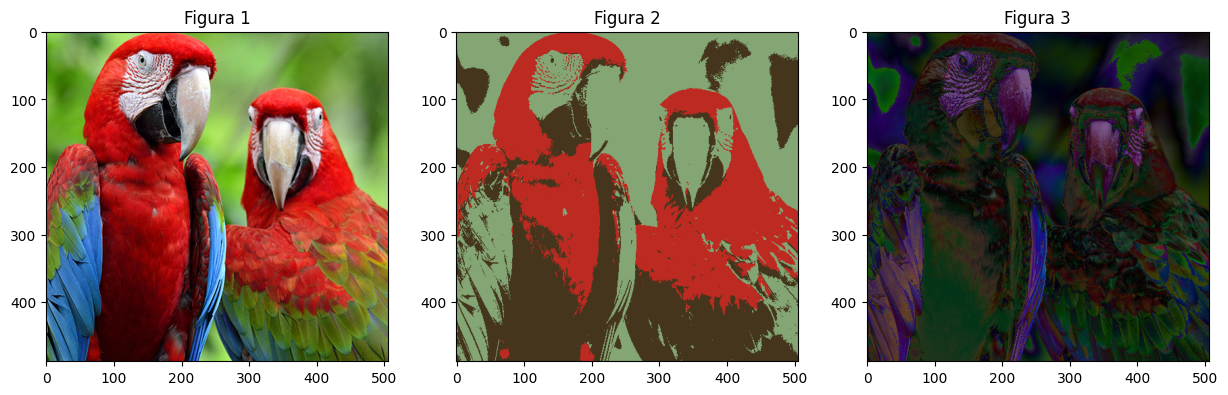

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.cluster import KMeans
from tqdm import tqdm
import os
def function_1(img, parameter):
    temp = np.reshape(img, (img.shape[0]*img.shape[1],3))
    model = KMeans(n_clusters=parameter, random_state=0, n_init=1).fit(temp)
    output = model.cluster_centers_[model.labels_]
    output = np.reshape(output,(img.shape[0],img.shape[1],3))
    return output
imagem = mpimg.imread('../data/araras.png')
output = function_1(imagem, 3)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,15))
ax1.imshow(imagem)
ax1.set_title("Figura 1")
ax2.imshow(output)
ax2.set_title(f"Figura 2")
ax3.imshow(np.abs(imagem - output))
ax3.set_title("Figura 3")
plt.show()


A Figura 1 é a imagem original. A Figura 2 é a classificação de cada pixel em um dos três clusteres analisados. Cada cluster representa uma das três cores que melhor agrupavam as amostras em três grupos. A figura 3 é a parte da imagem que não foi incorporada na classificação anterior. Nela, foi retirado de cada pixel o clusterno qual ele foi classificado. 'parameter' representa o número de clusteres que serão considerados na decomposição da imagem. Quanto maior o número de clusteres, mais cores serão consideradas na classificação, e a imagem resultante da Figura 2 se aproximará mais da imagem original. Já a Figura 3 se aproximará de uma imagem completamente preta, pois cada vez menos pixels serão classificados como parte do cluster errado.
parameter = 3:



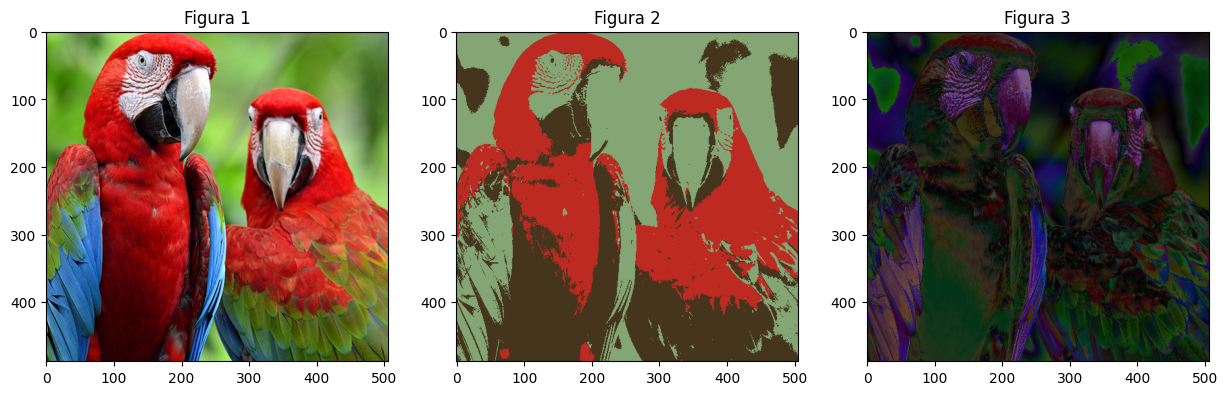

parameter = 10:



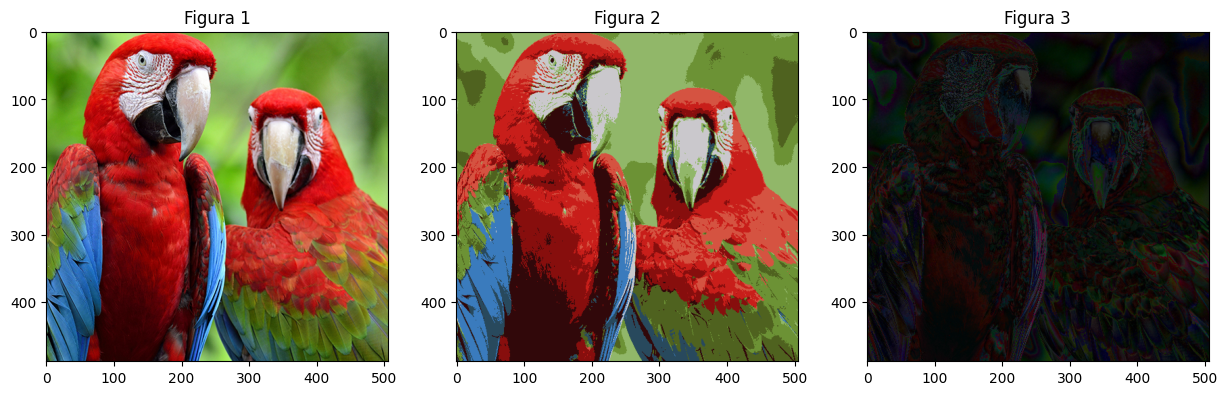

parameter = 30:



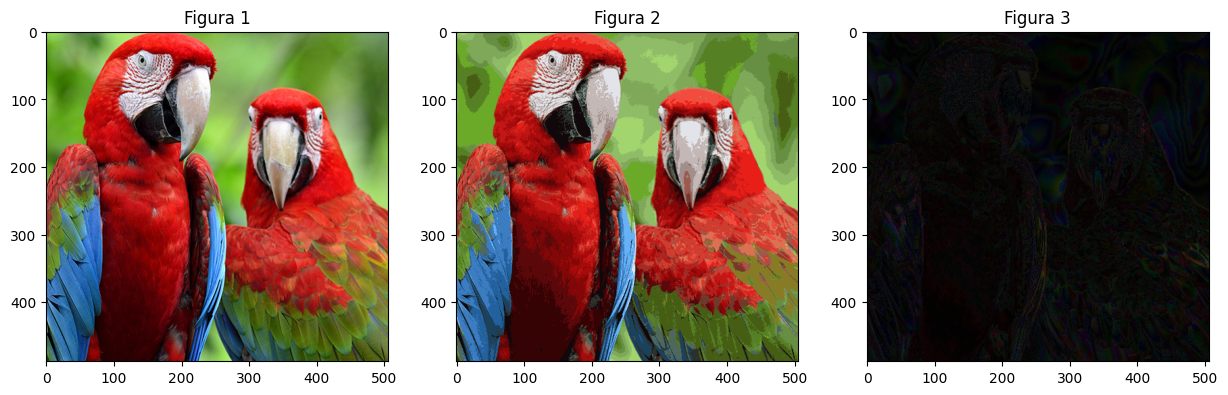

In [2]:
# a) Explique o que as Figuras 1, 2 e 3 representam no código acima e o impacto da variável parameter na Figura 2. Exiba o output do código acima para parameter=3, 10, 30.

print("A Figura 1 é a imagem original. A Figura 2 é a classificação de cada pixel em um dos três clusteres analisados. Cada cluster representa uma das três cores que " \
"melhor agrupavam as amostras em três grupos. A figura 3 é a parte da imagem que não foi incorporada na classificação anterior. Nela, foi retirado de cada pixel o cluster" \
"no qual ele foi classificado. 'parameter' representa o número de clusteres que serão considerados na decomposição da imagem. Quanto maior o número de clusteres, mais cores " \
"serão consideradas na classificação, e a imagem resultante da Figura 2 se aproximará mais da imagem original. Já a Figura 3 se aproximará de uma imagem completamente preta," \
" pois cada vez menos pixels serão classificados como parte do cluster errado.")

parameters = [3, 10, 30]
for parameter in parameters:
    output = function_1(imagem, parameter)
    print(f'parameter = {parameter}:\n')
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,15))
    ax1.imshow(imagem)
    ax1.set_title("Figura 1")
    ax2.imshow(output)
    ax2.set_title(f"Figura 2")
    ax3.imshow(np.abs(imagem - output))
    ax3.set_title("Figura 3")
    plt.show()

In [3]:
# (b) Em geral, um arquivo .png usa valores j/255, com j = 0, 1, . . . , 255 para a intensidade de cor (vermelho, verde ou azul) em cada pixel.
# Ou seja, cada intensidade é representada com no máximo log2 (256) = 8 bits por pixel e, portanto, cada pixel pode ser representado por até 
# 3 cores × 8 bits = 24 bits. Por outro lado, a function_1 retorna imagens comprimidas, isto é, em que o número de bits por pixel é potencialmente
# muito menor. Determine qual é o número de bits por pixel necessário em função de parameter

print('Considerando que cada classe terá a cor armazenada em uma matriz separada, precisamos apenas representar a classe na qual o pixel está inserido para reproduzir a imagem. Dessa forma, ' \
'o número de bits por pixel necessários será log2(parameter)') 

Considerando que cada classe terá a cor armazenada em uma matriz separada, precisamos apenas representar a classe na qual o pixel está inserido para reproduzir a imagem. Dessa forma, o número de bits por pixel necessários será log2(parameter)


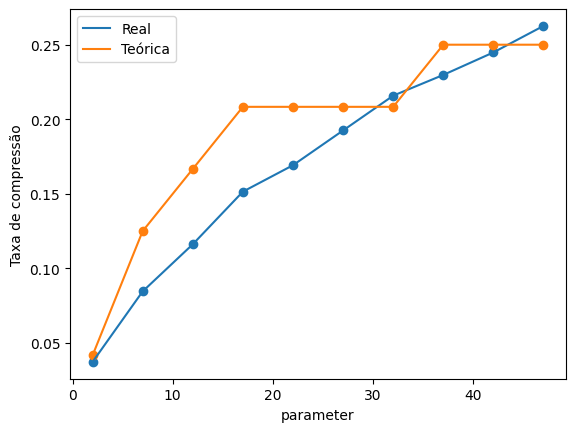

A taxa de compressão verificada é maior do que a taxa teórica para valores baixos de parameter, o que pode ser explicado pelas técnicasde compressão adotadas pelo formato PNG, que são mais eficientes para imagens com menos variação de cores. 


In [4]:
# (c) O código a seguir roda a função function_1 em um conjunto pré-definido de valores parameter e salva em uma lista a sua taxa de compressão,
# isto é, o tamanho em bits de cada output salvo dividido pelo tamanho em bits da imagem original. Faça um gráfico onde o eixo x é dado por 
# parameter_interval e o eixo y é dado pela taxa de compressão da imagem. Desenhe duas linhas, uma representando a taxa de compressão
# verificada na lista sizes e a outra representando a taxa de compressão teórica encontrada no item anterior. Comente o resultado.
os.makedirs('../results/', exist_ok=True)
parameter_interval = np.array(range(2, 50, 5))
image = mpimg.imread('../data/araras.png')

for i in parameter_interval:
    tmp = function_1(image, i)
    plt.imsave(f"../results/imagem_{i}.png", tmp)

original_size = os.path.getsize('../data/araras.png')
sizes = []
for i in parameter_interval:
    file_size = os.path.getsize(f'../results/imagem_{i}.png')
    sizes.append(file_size / original_size)
    

theoretical_sizes = np.ceil(np.log2(parameter_interval))/24

plt.scatter(parameter_interval, sizes)
plt.scatter(parameter_interval, theoretical_sizes)
plt.plot(parameter_interval, sizes, label='Real')
plt.plot(parameter_interval, theoretical_sizes, label='Teórica')
plt.xlabel('parameter')
plt.ylabel('Taxa de compressão')
plt.legend()
plt.show()

print('A taxa de compressão verificada é calculada considerando o arquivo em toda a sua extensão, o que inclui seus metadados, headers e técnicas de compressão do formato PNG.' \
'Em contrapartida, os valores teóricos consideravam apenas a equivalência bit a bit. Assim, a taxa de compressão real foi menor do que a taxa teórica para ' \
'valores baixos de parameter, o que pode ser explicado pelas técnicas de compressão adotadas pelo formato PNG, que são mais eficientes para imagens com menos variação de cores e a '
'menor quantidade de headers. À medida que o número de clusters aumenta, a taxa de compressão verificada se aproxima da taxa teórica, até que esta torna-se mais eficiente' \
'para valores mais altos de parameter, como pode ser visto na figura "../reports/figures/5/mora_params.png". Isso pode ser explicado pela presença de maior quantidade de' \
'metadados e menor eficiência das técnicas de compressão do formato PNG para imagens com maior variação de cores, o que é o caso das imagens resultantes da função function_1' \
'para valores mais altos de parameter.')

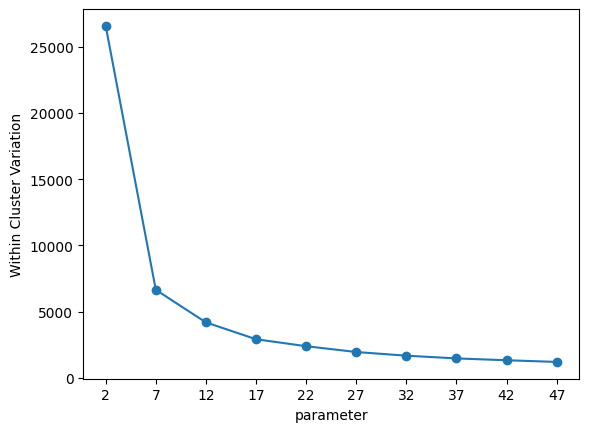

In [13]:
# d) Considere o código abaixo:
# O valor model.inertia_ representa a soma dos quadrados das distâncias dos pontos até o centro
# do cluster em que se encontram. Faça um gráfico desenhando para cada valor em parameter_interval
# seu respectivo valor na lista within_cluster_variation. Intuitivamente, como você usaria
# esse gráfico para escolher uma quantidade de clusters k apropriada para o problema? Justifique
# sua resposta e use o código abaixo para apresentar o resultado da imagem utilizando o valor de
# k que você encontrou.

def function_2(img, parameter):
    temp = np.reshape(img, (img.shape[0]*img.shape[1],3))
    model = KMeans(n_clusters=parameter, random_state=0, n_init=1).fit(temp)
    return model.inertia_

within_cluster_variation = []
for i in parameter_interval:
    image = mpimg.imread('../data/araras.png')
    within_cluster_variation.append(function_2(image, i))

plt.plot(parameter_interval, within_cluster_variation)
plt.scatter(parameter_interval, within_cluster_variation)
plt.xticks(parameter_interval)
plt.xlabel('parameter')
plt.ylabel('Within Cluster Variation')
plt.show()


Considerando o gráfico, um valor de k apropriado para o problema seria 12. A partir deste ponto, a distância média entre os pontos de uma classe e o centro do clusterreduz menos com o aumento do número de centróides. Antes dele, essa distância era grande demais. Em outras palavras, o trade-off entre compressão e reprodutibilidade teria um "joelho" neste ponto.


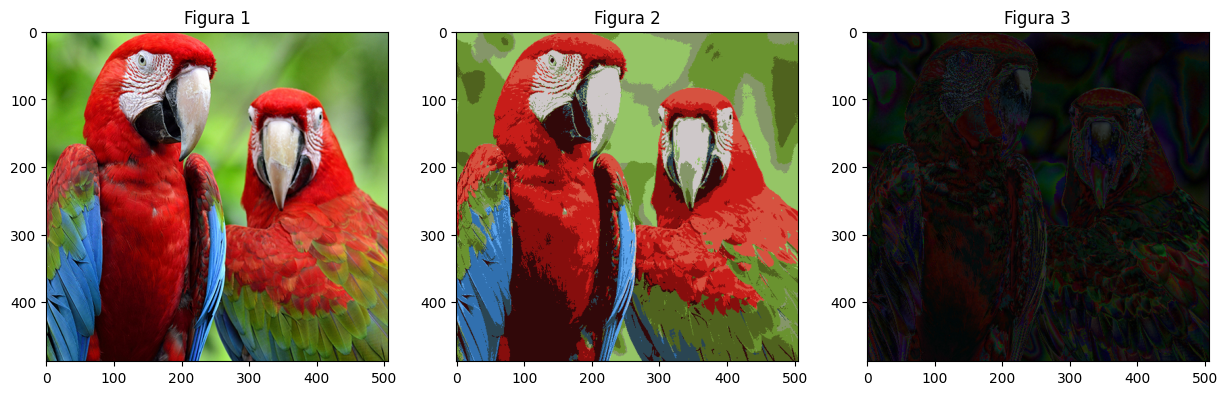

In [16]:
print('Considerando o gráfico, um valor de k apropriado para o problema seria 12. A partir deste ponto, a distância média entre os pontos de uma classe e o centro do cluster' \
'reduz menos com o aumento do número de centróides. Antes dele, essa distância era grande demais. Em outras palavras, o trade-off entre compressão e reprodutibilidade ' \
'teria um "joelho" neste ponto.A imagem à seguir apresenta o resultado da função function_1 para k=12, demonstrando que nesse ponto, a imagem mantem uma boa qualidade.')
k = 12
output = function_1(imagem, k)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,15))
ax1.imshow(imagem)
ax1.set_title("Figura 1")
ax2.imshow(output)
ax2.set_title(f"Figura 2")
ax3.imshow(np.abs(imagem - output))
ax3.set_title("Figura 3")
plt.show()

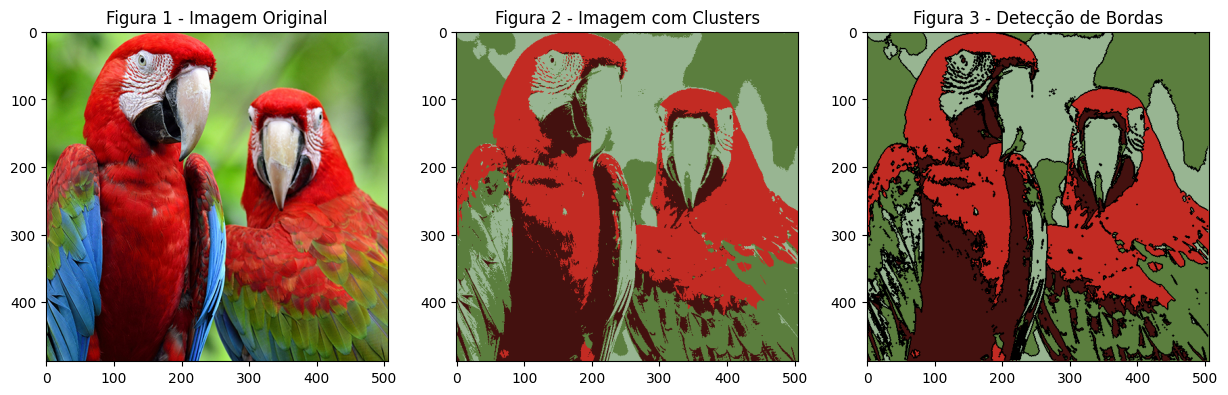

In [22]:
# (e) A técnica apresentada nos itens anteriores também pode ser usada para criação de um algoritmo
# de detecção de bordas. Para isso, podemos pintar de preto os pontos da imagem em que um de seus vizinhos (acima, abaixo, à esquerda e à direita) pertence a um cluster 
# diferente do seu. Lembrando que a cor preta é indicada pelo vetor (0, 0, 0), preencha o código a seguir para obter
# o efeito desejado. Ao final, exiba a imagem encontrada.

def function_3(img):
    res = img.copy()
    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            up = (img[i,j] != img[i+1,j]).any()
            down = (img[i,j] != img[i-1,j]).any()
            left = (img[i,j] != img[i,j-1]).any()
            right = (img[i,j] != img[i,j+1]).any()
            if up or down or left or right:
                res[i,j] = np.array([0,0,0])
    return res

imagem = mpimg.imread('../data/araras.png')
output = function_1(imagem, 4)
edge = function_3(output)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,15))
ax1.imshow(imagem)
ax1.set_title("Figura 1 - Imagem Original")
ax2.imshow(output)
ax2.set_title(f"Figura 2 - Imagem com Clusters")
ax3.imshow(edge)
ax3.set_title("Figura 3 - Detecção de Bordas")
plt.show()

100%|██████████| 9/9 [01:16<00:00,  8.54s/it]


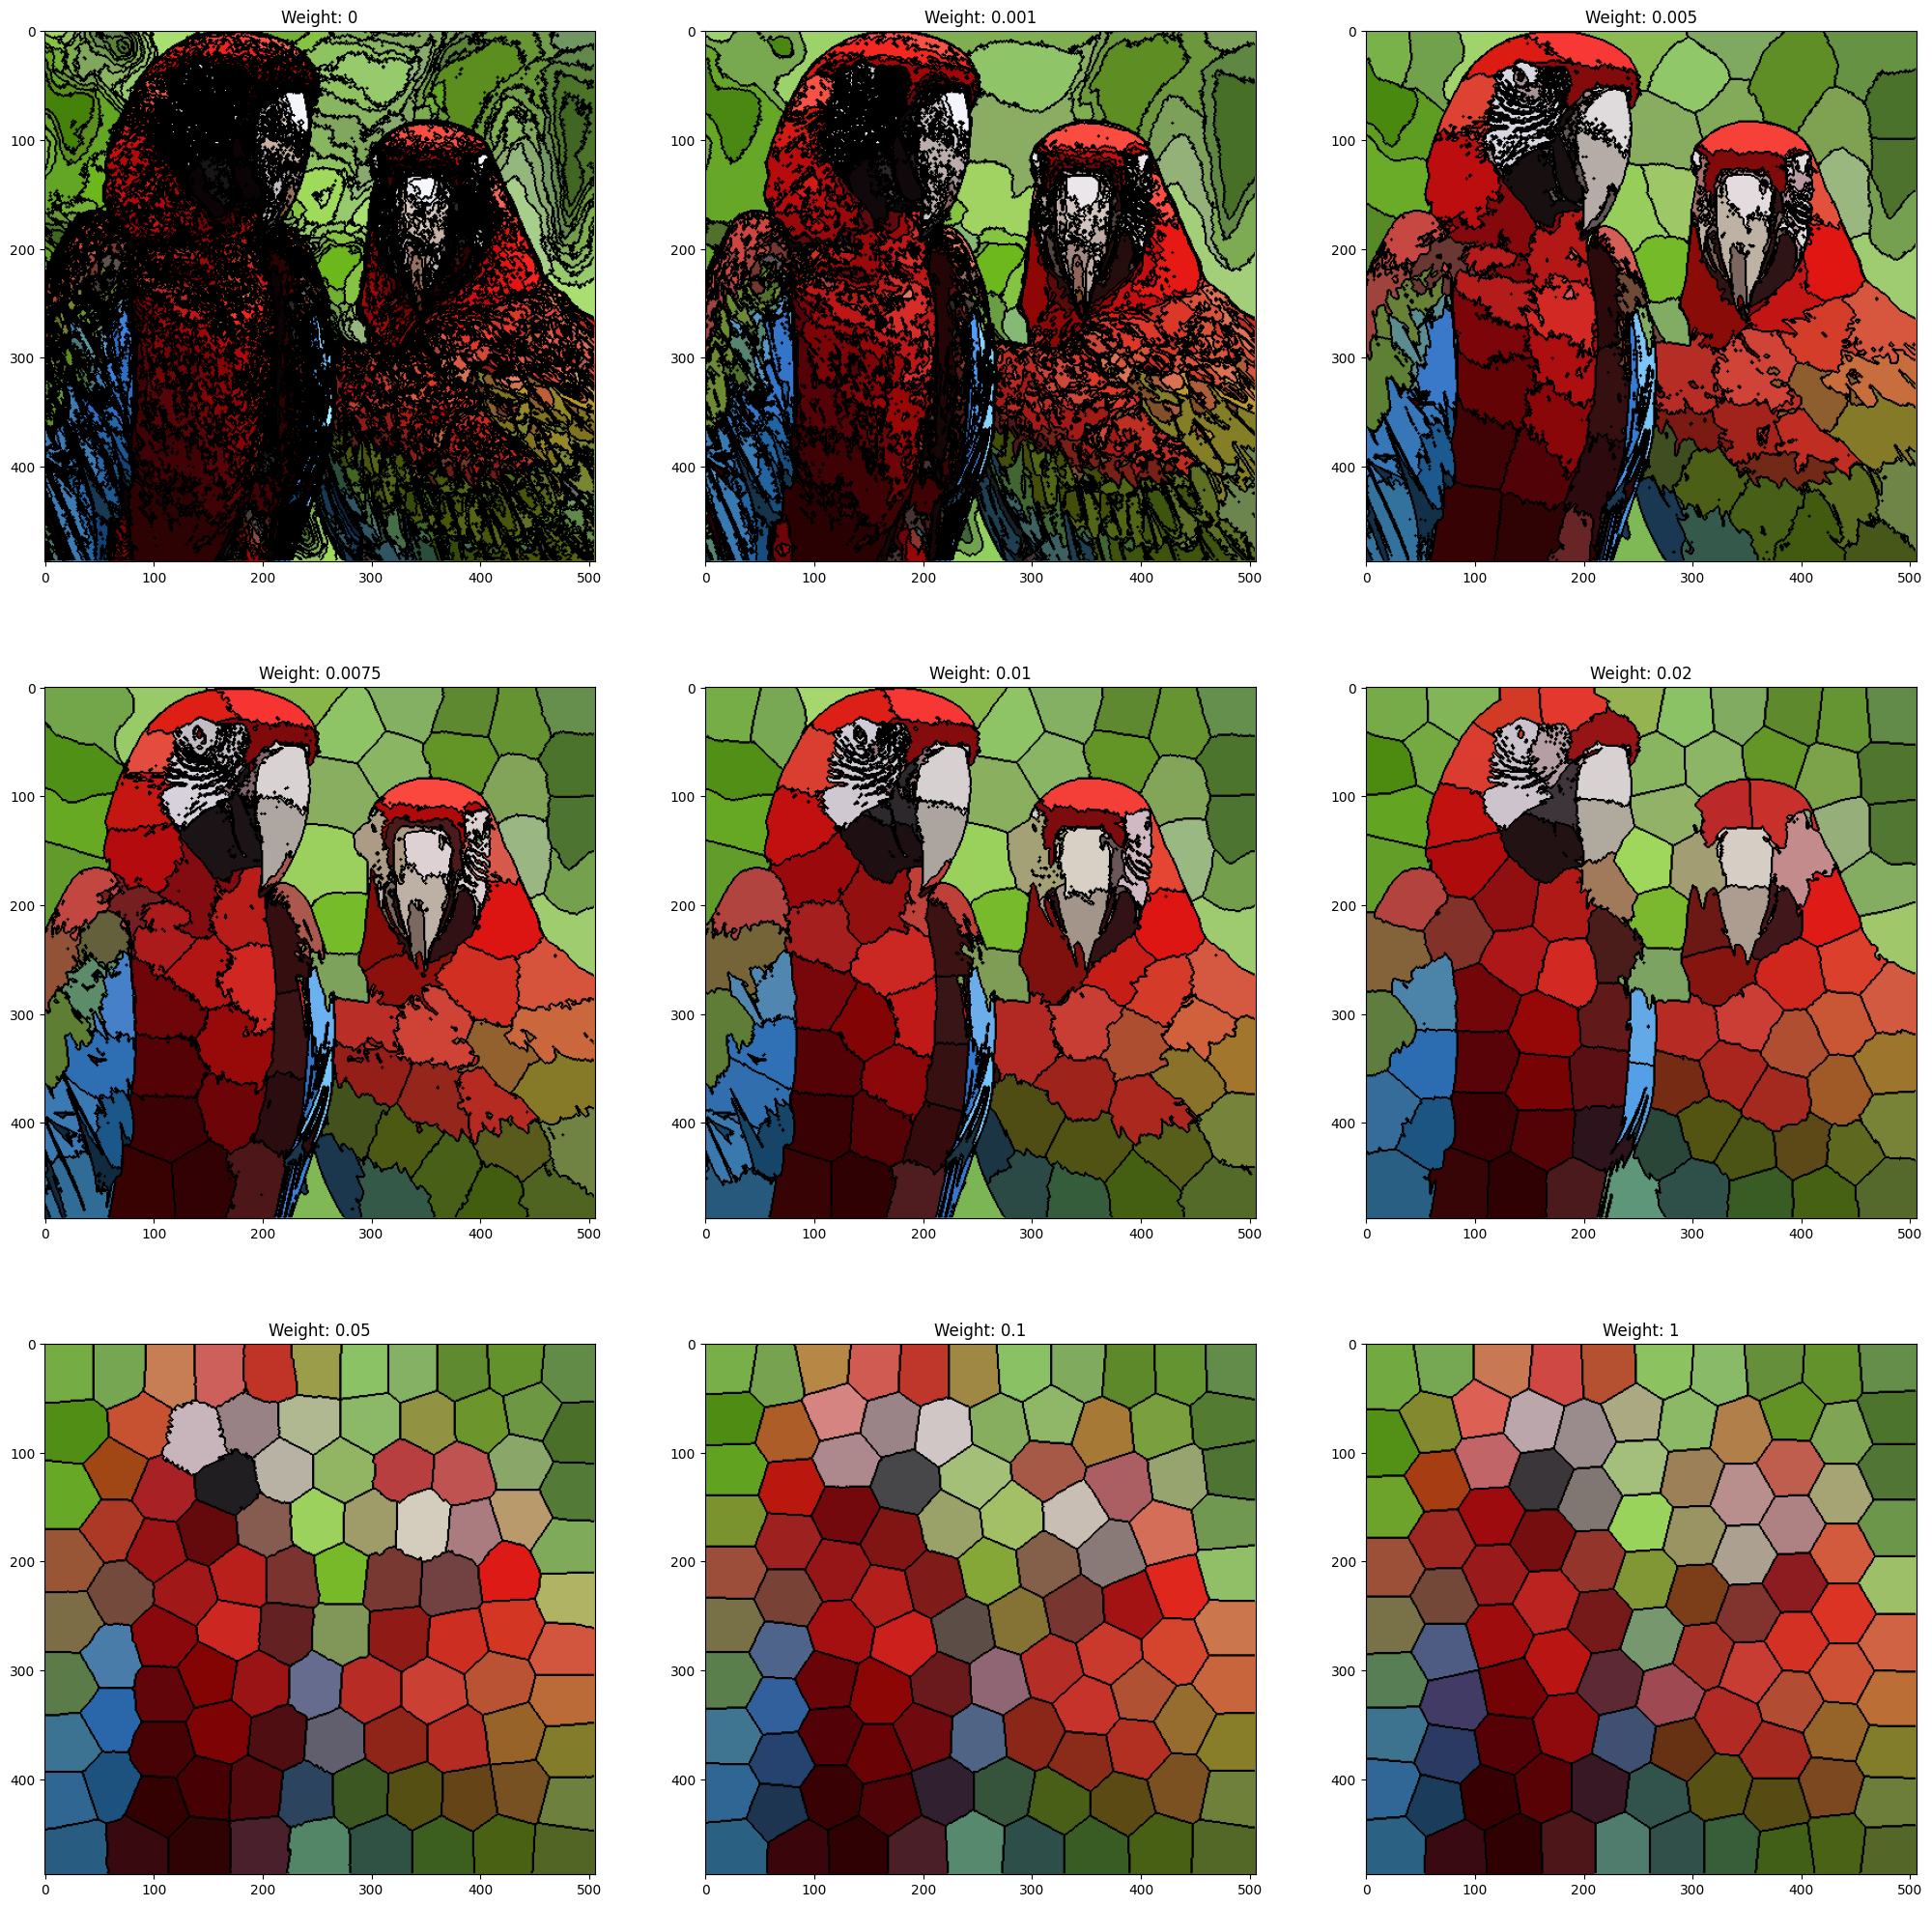

In [23]:
# (f ) Agora, suponha que além do vetor com as intensidades de vermelho, verde e azul, adicionemos
# também a coordenada x e y de cada pixel, com um certo peso w. Isso é implementado na função
# function_4 no código abaixo, que imprime o resultado para diferentes valores de w.
# A partir das figuras resultantes e do seu conhecimento do algoritmo de k-means, explique o
# efeito da inclusão das coordenadas x e y de cada pixel no vetor com as intensidades das cores.
# Discuta o impacto do peso w e, em particular, o formato regular dos contornos na figura quando
# w é grande.


def function_4(img, parameter, weight):
    tmp = img.copy()
    tmp = np.dstack((imagem, np.zeros((imagem.shape[0], imagem.shape[1]))))
    tmp = np.dstack((tmp, np.zeros((imagem.shape[0], imagem.shape[1]))))
    for i in range(tmp.shape[0]):
        for j in range(tmp.shape[1]):
            tmp[i,j, 3] = weight*i
            tmp[i,j, 4] = weight*j
    temp = np.reshape(tmp, (img.shape[0]*img.shape[1], 5))
    model = KMeans(n_clusters=parameter, random_state=0, n_init="auto").fit(temp)
    output = model.cluster_centers_[model.labels_]
    output = np.reshape(output,(img.shape[0],img.shape[1],5))
    return output[:,:,:3]
imagem = mpimg.imread('../data/araras.png')
k = 100
weights = [0, 0.001, 0.005, 0.0075, 0.01, 0.02, 0.05, 0.1, 1]
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(25,25))
for i, axis in tqdm(enumerate(axes.flatten()), total=len(weights)):
    axis.imshow(function_3(function_4(imagem, k, weight=weights[i])))
    axis.set_title(f"Weight: {weights[i]}")
plt.show()


In [24]:
print('A inclusão das coordenadas x e y adicionam informação espacial para o' \
'algorítmo de clusterização. Assim, além da similaridade das cores, ele também' \
'considerará a proximidade entre os pixeis. Os valores de w definem o quão sensível' \
'será o algoritmo à distância, de modo que valores pequenos de w fazem com que o' \
'método priorize mais as cores, enquanto valores maiores dão enfoque na posição. ' \
'As figuras resultandes indicam exatamente isto. Para w = 0, temos o algoritmo' \
'original, apenas com cores, e para w maiores que 0.05, as cores praticamente não importam, pois' \
'seus valores tem magnitude menor que a da posição de cada pixel. Nesta configuração,' \
'o contorno dos clusteres é regular já que a fronteira entre os grupos são basicamente os pontos equidistantes a' \
'dois ou, no caso das arestas entre três hexagonos, três centróides. Além disso, os centroides tendem a se organizar em um formato regular, já que esta configuração' \
'seria mais adequada para aumentar a pureza entre os clusters.')

A inclusão das coordenadas x e y adicionam informação espacial para oalgorítmo de clusterização. Assim, além da similaridade das cores, ele tambémconsiderará a proximidade entre os pixeis. Os valores de w definem o quão sensívelserá o algoritmo à distância, de modo que valores pequenos de w fazem com que ométodo priorize mais as cores, enquanto valores maiores dão enfoque na posição. As figuras resultandes indicam exatamente isto. Para w = 0, temos o algoritmooriginal, apenas com cores, e para w maiores que 0.05, as cores praticamente não importam, poisseus valores tem magnitude menor que a da posição de cada pixel. Nesta configuração,o contorno dos clusteres é regular já que a fronteira entre os grupos são basicamente os pontos equidistantes adois ou, no caso das arestas entre três hexagonos, três centróides. Além disso, os centroides tendem a se organizar em um formato regular, já que esta configuraçãoseria mais adequada para aumentar a pureza entre os clusters.
